In [11]:
# === Optimized EdgeFormerNet++ Training Code for Dice > 0.85 ===  - TRAINING THE MODEL

import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import (
    LayerNormalization, MultiHeadAttention, Dense, Dropout, Add,
    GlobalAveragePooling2D, Multiply, Conv2D, Reshape, Concatenate,
    BatchNormalization, Conv2DTranspose, Activation, ReLU, MaxPooling2D
)
from tensorflow.keras.utils import Sequence
import albumentations as A
from albumentations.core.composition import OneOf

# === CONFIG ===
img_height, img_width = 384, 256
batch_size = 4
epochs = 400
initializer = tf.keras.initializers.GlorotUniform(seed=42)

# === Mask Color Mapping ===
def extract_unique_colors(mask_dir):
    unique_colors = set()
    for fname in os.listdir(mask_dir):
        if fname.endswith(('.png', '.bmp')):
            mask = np.array(Image.open(os.path.join(mask_dir, fname)).convert('RGB'))
            colors = np.unique(mask.reshape(-1, 3), axis=0)
            for c in map(tuple, colors):
                unique_colors.add(c)
    return sorted(list(unique_colors))

train_lbl_dir = r"D:\layer\oct_dataset\oct_dataset\train\mask"
UNIQUE_COLORS = extract_unique_colors(train_lbl_dir)
COLOR_TO_INDEX = {color: idx for idx, color in enumerate(UNIQUE_COLORS)}
INDEX_TO_COLOR = {idx: color for color, idx in COLOR_TO_INDEX.items()}
num_classes = len(COLOR_TO_INDEX)

# === Load Image/Mask Pair ===
def load_image_mask_pair(image_path, mask_path):
    image = Image.open(image_path).resize((img_width, img_height))
    image = np.array(image, dtype=np.float32) / 255.0
    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)

    mask = Image.open(mask_path).convert('RGB').resize((img_width, img_height), resample=Image.NEAREST)
    mask = np.array(mask)
    mask_indexed = np.zeros((img_height, img_width), dtype=np.uint8)
    for color, idx in COLOR_TO_INDEX.items():
        mask_indexed[np.all(mask == color, axis=-1)] = idx
    return image, mask_indexed

# === Dataset Loader ===
def load_dataset(image_dir, mask_dir):
    image_files = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(('.png', '.bmp'))])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith(('.png', '.bmp'))])
    images, masks = [], []
    for img_path, msk_path in zip(image_files, mask_files):
        img, msk = load_image_mask_pair(img_path, msk_path)
        images.append(img)
        masks.append(msk)
    return np.array(images), np.array(masks)

# === Augmentation ===
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ElasticTransform(p=0.4),
    A.GridDistortion(p=0.2),
    A.RandomBrightnessContrast(p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.CLAHE(p=0.2),
    OneOf([
        A.GaussianBlur(blur_limit=(3, 5)),
        A.MedianBlur(blur_limit=5),
        A.GaussNoise(var_limit=(10.0, 50.0))
    ], p=0.3)
])

# === Custom Data Generator ===
class CustomDataGenerator(Sequence):
    def __init__(self, images, masks, batch_size, transform=None):
        self.images = images
        self.masks = masks
        self.batch_size = batch_size
        self.transform = transform

    def __len__(self):
        return len(self.images) // self.batch_size

    def __getitem__(self, idx):
        batch_images = self.images[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_masks = self.masks[idx * self.batch_size:(idx + 1) * self.batch_size]
        aug_imgs, aug_masks = [], []
        for img, mask in zip(batch_images, batch_masks):
            augmented = self.transform(image=img, mask=mask) if self.transform else {'image': img, 'mask': mask}
            aug_imgs.append(np.resize(augmented['image'], (img_height, img_width, 3)).astype(np.float32))
            aug_masks.append(np.resize(augmented['mask'], (img_height, img_width)).astype(np.uint8))
        return np.stack(aug_imgs), np.stack(aug_masks)

# === Loss Functions ===
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2])
    return 1.0 - tf.reduce_mean((2. * intersection + smooth) / (union + smooth))

def tversky_loss(y_true, y_pred, alpha=0.6, beta=0.4, smooth=1e-6):
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
    TP = tf.reduce_sum(y_true * y_pred, axis=[1,2])
    FP = tf.reduce_sum((1 - y_true) * y_pred, axis=[1,2])
    FN = tf.reduce_sum(y_true * (1 - y_pred), axis=[1,2])
    return tf.reduce_mean(1 - (TP + smooth) / (TP + alpha * FP + beta * FN + smooth))

def hybrid_loss(y_true, y_pred):
    return 0.5 * dice_loss(y_true, y_pred) + 0.5 * tversky_loss(y_true, y_pred)

def dice_metric(y_true, y_pred, smooth=1e-6):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.one_hot(y_pred, depth=num_classes)
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2])
    return tf.reduce_mean((2. * intersection + smooth) / (union + smooth))

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.one_hot(y_pred, depth=num_classes)
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2]) - intersection
    return tf.reduce_mean((intersection + smooth) / (union + smooth))

# === Load Data ===
train_img_dir = r"D:\layer\oct_dataset\oct_dataset\train\img"
val_img_dir = r"D:\layer\oct_dataset\oct_dataset\eval\img"
val_lbl_dir = r"D:\layer\oct_dataset\oct_dataset\eval\mask"
X_train, y_train = load_dataset(train_img_dir, train_lbl_dir)
X_val, y_val = load_dataset(val_img_dir, val_lbl_dir)
train_gen = CustomDataGenerator(X_train, y_train, batch_size=batch_size, transform=train_transform)
val_gen = CustomDataGenerator(X_val, y_val, batch_size=batch_size)

# === Build Model ===
model = build_edgeformernet(input_shape=(img_height, img_width, 3), num_classes=num_classes)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=hybrid_loss,
              metrics=[dice_metric, iou_metric])

# === Training Callbacks ===
callbacks = [
    #tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("EdgeFormer_Dice85_best_val_loss_{val_loss:.6f}.h5", save_best_only=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, min_lr=1e-6)
]

# === Train ===
history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks)

Epoch 1/400
37/37 [==============================] - 9s 148ms/step - loss: 0.9134 - dice_metric: 0.1251 - iou_metric: 0.0893 - val_loss: 0.9446 - val_dice_metric: 0.0956 - val_iou_metric: 0.0608 - lr: 0.0010
Epoch 2/400
37/37 [==============================] - 5s 131ms/step - loss: 0.8502 - dice_metric: 0.2012 - iou_metric: 0.1458 - val_loss: 0.8598 - val_dice_metric: 0.1886 - val_iou_metric: 0.1355 - lr: 0.0010
Epoch 3/400
37/37 [==============================] - 4s 116ms/step - loss: 0.7856 - dice_metric: 0.2689 - iou_metric: 0.1967 - val_loss: 0.8852 - val_dice_metric: 0.2187 - val_iou_metric: 0.1586 - lr: 0.0010
Epoch 4/400
37/37 [==============================] - 5s 122ms/step - loss: 0.7349 - dice_metric: 0.3048 - iou_metric: 0.2262 - val_loss: 0.8765 - val_dice_metric: 0.1452 - val_iou_metric: 0.1179 - lr: 0.0010
Epoch 5/400
37/37 [==============================] - 5s 131ms/step - loss: 0.6787 - dice_metric: 0.3620 - iou_metric: 0.2687 - val_loss: 0.7507 - val_dice_metric: 0.352

Detected unique colors: [(0, 0, 0), (26, 26, 26), (51, 51, 51), (77, 77, 77), (102, 102, 102), (128, 128, 128), (153, 153, 153), (179, 179, 179), (204, 204, 204), (230, 230, 230), (255, 255, 255)]
Detected number of classes: 11
Using class names: ['BG', 'RNFL', 'GCL', 'IPL', 'INL', 'OPL', 'ONL', 'IS/OS', 'RPE', 'Choroid', 'Disc']
Selected target layers: ['RNFL', 'GCL', 'IPL', 'INL', 'OPL', 'ONL', 'IS/OS', 'RPE', 'Choroid']
Selected target indices: [1, 2, 3, 4, 5, 6, 7, 8, 9]

Loading dataset...
X_test shape: (48, 384, 256, 3)
y_test shape: (48, 384, 256)

Loading model...

===== Model Complexity =====
Total Parameters : 7,369,469
Weight Memory    : 28.11 MB
FLOPs            : 45.52 GFLOPs

Running inference...
48/48 [==============================] - 2s 24ms/step

===== Inference Performance =====
Total Time       : 2.2592 sec
Time per Image   : 47.07 ms
FPS              : 21.25

===== PER-LAYER RESULTS (Selected 9 Layers Only) =====
RNFL       | Dice: 82.34 ± 6.49 | IoU: 70.48 ± 9.12 

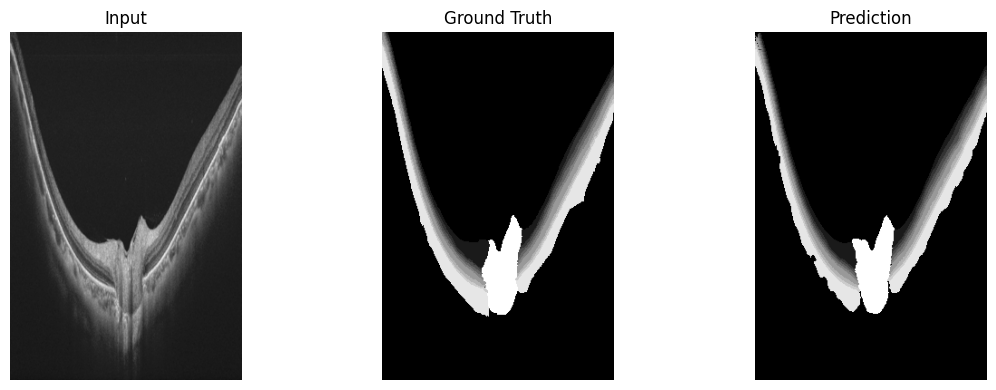

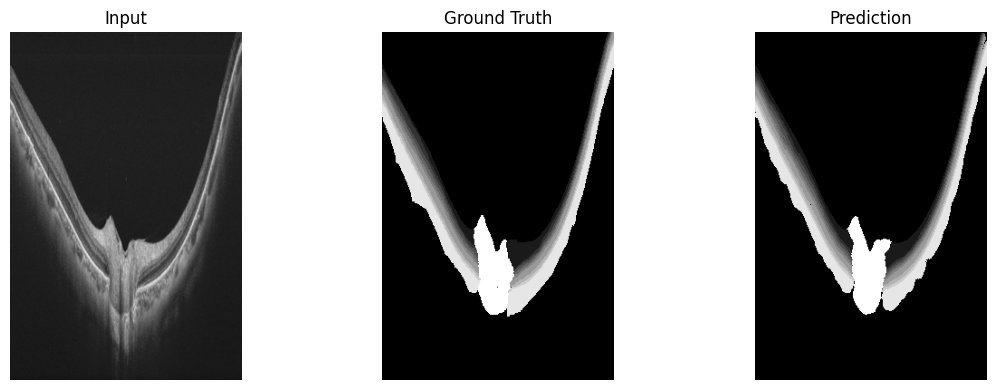

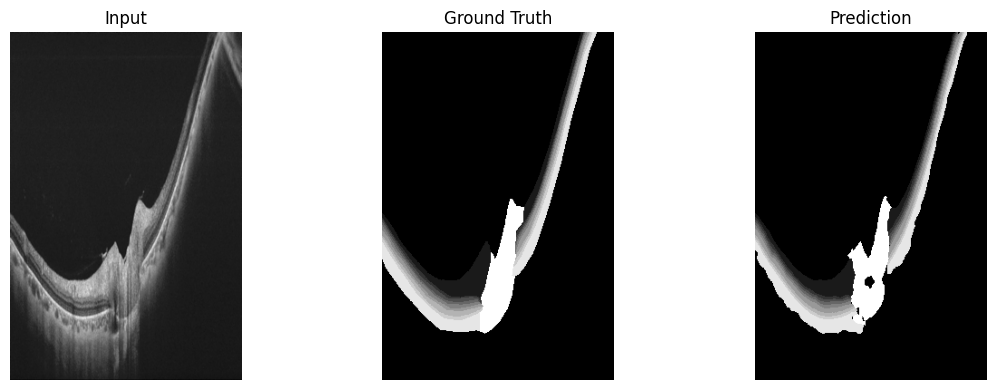

In [4]:
# =========================================================
# COMPLETE TESTING SCRIPT FOR MGU DATASET
# Computes metrics ONLY for these 9 layers:
# RNFL, GCL, IPL, INL, OPL, ONL, IS/OS, RPE, Choroid
#
# Excludes:
# - BG
# - Disc
#
# Final outputs:
# - Mean Dice
# - Mean IoU
# - Mean PA
# reported as mean ± std over test images
# =========================================================

import os
import time
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
img_height, img_width = 384, 256
test_img_dir = r"D:\layer\oct_dataset\oct_dataset\test\img"
test_lbl_dir = r"D:\layer\oct_dataset\oct_dataset\test\mask"
model_path   = r"C:\Users\VPG\OCT_LAYER\EdgeFormer_Dice85_best_val_loss_0.220065.h5"

# IMPORTANT:
# This order must match the class index order in your masks.
# If your masks use a different order, update this list accordingly.
LAYER_NAMES = [
    "BG",       # 0
    "RNFL",     # 1
    "GCL",      # 2
    "IPL",      # 3
    "INL",      # 4
    "OPL",      # 5
    "ONL",      # 6
    "IS/OS",    # 7
    "RPE",      # 8
    "Choroid",  # 9
    "Disc"      # 10
]

# Metrics will be computed ONLY for these layers
TARGET_LAYERS = [
    "RNFL",
    "GCL",
    "IPL",
    "INL",
    "OPL",
    "ONL",
    "IS/OS",
    "RPE",
    "Choroid"
]

# =========================================================
# CUSTOM LAYER
# =========================================================
class PositionalEncoding(tf.keras.layers.Layer):
    def call(self, x):
        seq_len = tf.shape(x)[1]
        d_model = tf.shape(x)[2]
        pos = tf.cast(tf.range(seq_len)[:, tf.newaxis], tf.float32)
        i = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
        angle_rates = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        angle_rads = pos * angle_rates
        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = tf.expand_dims(pos_encoding, axis=0)
        return x + pos_encoding

# =========================================================
# EXTRACT UNIQUE COLORS FROM MASKS
# =========================================================
def extract_unique_colors(mask_dir):
    unique_colors = set()
    for fname in os.listdir(mask_dir):
        if fname.lower().endswith(('.png', '.bmp', '.jpg', '.jpeg', '.tif', '.tiff')):
            mask = np.array(Image.open(os.path.join(mask_dir, fname)).convert('RGB'))
            colors = np.unique(mask.reshape(-1, 3), axis=0)
            for c in map(tuple, colors):
                unique_colors.add(c)
    return sorted(list(unique_colors))

UNIQUE_COLORS = extract_unique_colors(test_lbl_dir)
COLOR_TO_INDEX = {color: idx for idx, color in enumerate(UNIQUE_COLORS)}
INDEX_TO_COLOR = {idx: color for color, idx in COLOR_TO_INDEX.items()}
num_classes = len(COLOR_TO_INDEX)

print("Detected unique colors:", UNIQUE_COLORS)
print("Detected number of classes:", num_classes)

if len(LAYER_NAMES) != num_classes:
    print("\n[WARNING]")
    print(f"LAYER_NAMES has {len(LAYER_NAMES)} entries but dataset has {num_classes} classes.")
    print("Please correct LAYER_NAMES to exactly match your mask class order.\n")
    LAYER_NAMES = [f"Layer_{i}" for i in range(num_classes)]

print("Using class names:", LAYER_NAMES)

# =========================================================
# GET TARGET INDICES
# =========================================================
missing_layers = [name for name in TARGET_LAYERS if name not in LAYER_NAMES]
if len(missing_layers) > 0:
    raise ValueError(f"These target layers are missing in LAYER_NAMES: {missing_layers}")

target_indices = [LAYER_NAMES.index(name) for name in TARGET_LAYERS]
print("Selected target layers:", TARGET_LAYERS)
print("Selected target indices:", target_indices)

# =========================================================
# LOAD IMAGE AND MASK
# =========================================================
def load_image_mask_pair(image_path, mask_path):
    image = Image.open(image_path).resize((img_width, img_height))
    image = np.array(image, dtype=np.float32) / 255.0

    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)

    mask = Image.open(mask_path).convert('RGB').resize(
        (img_width, img_height),
        resample=Image.NEAREST
    )
    mask = np.array(mask)

    mask_indexed = np.zeros((img_height, img_width), dtype=np.int32)
    for color, idx in COLOR_TO_INDEX.items():
        mask_indexed[np.all(mask == color, axis=-1)] = idx

    return image, mask_indexed

# =========================================================
# LOAD DATASET
# =========================================================
def load_dataset(image_dir, mask_dir):
    image_files = sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith(('.png', '.bmp', '.jpg', '.jpeg', '.tif', '.tiff'))
    ])

    mask_files = sorted([
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith(('.png', '.bmp', '.jpg', '.jpeg', '.tif', '.tiff'))
    ])

    if len(image_files) != len(mask_files):
        raise ValueError(f"Mismatch: {len(image_files)} images vs {len(mask_files)} masks")

    images = []
    masks = []

    for img_path, msk_path in zip(image_files, mask_files):
        img, msk = load_image_mask_pair(img_path, msk_path)
        images.append(img)
        masks.append(msk)

    return np.array(images), np.array(masks)

# =========================================================
# METRIC FUNCTIONS
# =========================================================
def dice_score_binary(gt, pred, smooth=1e-6):
    intersection = np.sum(gt * pred)
    denom = np.sum(gt) + np.sum(pred)
    return (2.0 * intersection + smooth) / (denom + smooth)

def iou_score_binary(gt, pred, smooth=1e-6):
    intersection = np.sum(gt * pred)
    union = np.sum(gt) + np.sum(pred) - intersection
    return (intersection + smooth) / (union + smooth)

def pa_score_binary(gt_mask, pred_mask, smooth=1e-6):
    total = np.sum(gt_mask)
    correct = np.sum(pred_mask & gt_mask)
    return (correct + smooth) / (total + smooth)

def overall_pixel_accuracy_single(y_true, y_pred, smooth=1e-6):
    correct = np.sum(y_true == y_pred)
    total = y_true.size
    return (correct + smooth) / (total + smooth)

# =========================================================
# MODEL FLOPs
# =========================================================
def get_flops(model):
    try:
        from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

        input_shape = (1, img_height, img_width, 3)
        concrete_func = tf.function(lambda x: model(x))
        concrete_func = concrete_func.get_concrete_function(
            tf.TensorSpec(input_shape, tf.float32)
        )

        frozen_func = convert_variables_to_constants_v2(concrete_func)
        graph_def = frozen_func.graph.as_graph_def()

        with tf.Graph().as_default() as graph:
            tf.graph_util.import_graph_def(graph_def, name='')
            run_meta = tf.compat.v1.RunMetadata()
            opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

            flops = tf.compat.v1.profiler.profile(
                graph=graph,
                run_meta=run_meta,
                cmd='op',
                options=opts
            )

        return flops.total_float_ops

    except Exception as e:
        print("FLOPs calculation failed:", e)
        return None

# =========================================================
# VISUALIZATION
# =========================================================
def label_to_color(mask):
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for label, color in INDEX_TO_COLOR.items():
        color_mask[mask == label] = color
    return color_mask

def plot_predictions(X, y_true, y_pred, n=3):
    n = min(n, len(X))
    for i in range(n):
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(X[i])
        plt.title("Input")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(label_to_color(y_true[i]))
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(label_to_color(y_pred[i]))
        plt.title("Prediction")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# =========================================================
# MAIN
# =========================================================
print("\nLoading dataset...")
X_test, y_test = load_dataset(test_img_dir, test_lbl_dir)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nLoading model...")
model = load_model(
    model_path,
    compile=False,
    custom_objects={"PositionalEncoding": PositionalEncoding}
)

# =========================================================
# MODEL COMPLEXITY
# =========================================================
total_params = model.count_params()
weight_memory_mb = total_params * 4 / (1024 ** 2)
flops = get_flops(model)

print("\n===== Model Complexity =====")
print(f"Total Parameters : {total_params:,}")
print(f"Weight Memory    : {weight_memory_mb:.2f} MB")
if flops is not None:
    print(f"FLOPs            : {flops / 1e9:.2f} GFLOPs")

# =========================================================
# INFERENCE
# =========================================================
print("\nRunning inference...")
start_time = time.time()
y_pred_prob = model.predict(X_test, batch_size=1, verbose=1)
end_time = time.time()

y_pred_label = np.argmax(y_pred_prob, axis=-1)

total_time = end_time - start_time
time_per_image = total_time / len(X_test)
fps = len(X_test) / total_time

print("\n===== Inference Performance =====")
print(f"Total Time       : {total_time:.4f} sec")
print(f"Time per Image   : {time_per_image * 1000:.2f} ms")
print(f"FPS              : {fps:.2f}")

# =========================================================
# IMAGE-WISE METRICS ON SELECTED 9 LAYERS ONLY
# =========================================================
dice_img_scores = []
iou_img_scores = []
pa_img_scores = []

# Optional: per-layer stats also
dice_per_layer_all = []
iou_per_layer_all = []
pa_per_layer_all = []

for i in range(len(y_test)):
    yt = y_test[i]
    yp = y_pred_label[i]

    dice_this_img = []
    iou_this_img = []
    pa_this_img = []

    for cls in target_indices:
        gt = (yt == cls).astype(np.float32)
        pred = (yp == cls).astype(np.float32)

        gt_bool = (yt == cls)
        pred_bool = (yp == cls)

        dice = dice_score_binary(gt, pred)
        iou = iou_score_binary(gt, pred)
        pa = pa_score_binary(gt_bool, pred_bool)

        dice_this_img.append(dice)
        iou_this_img.append(iou)
        pa_this_img.append(pa)

    dice_this_img = np.array(dice_this_img)
    iou_this_img = np.array(iou_this_img)
    pa_this_img = np.array(pa_this_img)

    dice_per_layer_all.append(dice_this_img)
    iou_per_layer_all.append(iou_this_img)
    pa_per_layer_all.append(pa_this_img)

    # Mean across selected 9 layers for this image
    dice_img_scores.append(np.mean(dice_this_img))
    iou_img_scores.append(np.mean(iou_this_img))
    pa_img_scores.append(np.mean(pa_this_img))

dice_img_scores = np.array(dice_img_scores)
iou_img_scores = np.array(iou_img_scores)
pa_img_scores = np.array(pa_img_scores)

dice_per_layer_all = np.array(dice_per_layer_all)   # [N, 9]
iou_per_layer_all = np.array(iou_per_layer_all)     # [N, 9]
pa_per_layer_all = np.array(pa_per_layer_all)       # [N, 9]

# =========================================================
# FINAL RESULTS: MEAN ± STD
# =========================================================
mean_dice = np.mean(dice_img_scores)
std_dice = np.std(dice_img_scores)

mean_iou = np.mean(iou_img_scores)
std_iou = np.std(iou_img_scores)

mean_pa = np.mean(pa_img_scores)
std_pa = np.std(pa_img_scores)

# =========================================================
# OPTIONAL: PER-LAYER RESULTS
# =========================================================
dice_layer_mean = np.mean(dice_per_layer_all, axis=0)
dice_layer_std = np.std(dice_per_layer_all, axis=0)

iou_layer_mean = np.mean(iou_per_layer_all, axis=0)
iou_layer_std = np.std(iou_per_layer_all, axis=0)

pa_layer_mean = np.mean(pa_per_layer_all, axis=0)
pa_layer_std = np.std(pa_per_layer_all, axis=0)

print("\n===== PER-LAYER RESULTS (Selected 9 Layers Only) =====")
for j, name in enumerate(TARGET_LAYERS):
    print(
        f"{name:10s} | "
        f"Dice: {dice_layer_mean[j]*100:.2f} ± {dice_layer_std[j]*100:.2f} | "
        f"IoU: {iou_layer_mean[j]*100:.2f} ± {iou_layer_std[j]*100:.2f} | "
        f"PA: {pa_layer_mean[j]*100:.2f} ± {pa_layer_std[j]*100:.2f}"
    )

# =========================================================
# FINAL REQUIRED OUTPUT
# =========================================================
print("\n===== FINAL RESULTS (ONLY RNFL to Choroid) =====")
print(f"Mean Dice : {mean_dice*100:.2f} ± {std_dice*100:.2f}")
print(f"Mean IoU  : {mean_iou*100:.2f} ± {std_iou*100:.2f}")
print(f"Mean PA   : {mean_pa*100:.2f} ± {std_pa*100:.2f}")

# =========================================================
# SAVE RESULTS
# =========================================================
save_path = "mgu_selected_9_layers_results.txt"
with open(save_path, "w") as f:
    f.write("===== PER-LAYER RESULTS (Selected 9 Layers Only) =====\n")
    for j, name in enumerate(TARGET_LAYERS):
        f.write(
            f"{name:10s} | "
            f"Dice: {dice_layer_mean[j]*100:.2f} ± {dice_layer_std[j]*100:.2f} | "
            f"IoU: {iou_layer_mean[j]*100:.2f} ± {iou_layer_std[j]*100:.2f} | "
            f"PA: {pa_layer_mean[j]*100:.2f} ± {pa_layer_std[j]*100:.2f}\n"
        )

    f.write("\n===== FINAL RESULTS (ONLY RNFL to Choroid) =====\n")
    f.write(f"Mean Dice : {mean_dice*100:.2f} ± {std_dice*100:.2f}\n")
    f.write(f"Mean IoU  : {mean_iou*100:.2f} ± {std_iou*100:.2f}\n")
    f.write(f"Mean PA   : {mean_pa*100:.2f} ± {std_pa*100:.2f}\n")

    f.write("\n===== Model Complexity =====\n")
    f.write(f"Total Parameters : {total_params:,}\n")
    f.write(f"Weight Memory    : {weight_memory_mb:.2f} MB\n")
    if flops is not None:
        f.write(f"FLOPs            : {flops / 1e9:.2f} GFLOPs\n")

    f.write("\n===== Inference Performance =====\n")
    f.write(f"Total Time       : {total_time:.4f} sec\n")
    f.write(f"Time per Image   : {time_per_image * 1000:.2f} ms\n")
    f.write(f"FPS              : {fps:.2f}\n")

print(f"\nResults saved to: {save_path}")

# =========================================================
# OPTIONAL LATEX-FRIENDLY OUTPUT
# =========================================================
print("\n===== LATEX-FRIENDLY FINAL OUTPUT =====")
print(f"{mean_dice*100:.2f} $\\pm$ {std_dice*100:.2f}  &  {mean_iou*100:.2f} $\\pm$ {std_iou*100:.2f}  &  {mean_pa*100:.2f} $\\pm$ {std_pa*100:.2f}")

# =========================================================
# OPTIONAL VISUALIZATION
# =========================================================
plot_predictions(X_test, y_test, y_pred_label, n=3)